In [1]:
# Import necessary libraries
import pandas as pd
from sklearn.preprocessing import LabelEncoder
from sklearn.naive_bayes import CategoricalNB
from sklearn.metrics import accuracy_score, classification_report
import matplotlib.pyplot as plt

In [2]:
# Load the training and test datasets
# Ensure to replace the file paths with the correct paths if not running in the same environment.
train_data = pd.read_csv('/content/play_tennis_train.csv')
test_data = pd.read_csv('/content/play_tennis_train.csv')


In [3]:
# Step 1: Explore the dataset
# Display the first few rows to understand the structure of the data
print("Training Data Sample:")
print(train_data.head())


Training Data Sample:
  day   outlook  temp humidity    wind play
0  D1     Sunny   Hot     High    Weak   No
1  D2     Sunny   Hot     High  Strong   No
2  D3  Overcast   Hot     High    Weak  Yes
3  D4      Rain  Mild     High    Weak  Yes
4  D5      Rain  Cool   Normal    Weak  Yes


In [4]:
print("\nTest Data Sample:")
print(test_data.head())


Test Data Sample:
  day   outlook  temp humidity    wind play
0  D1     Sunny   Hot     High    Weak   No
1  D2     Sunny   Hot     High  Strong   No
2  D3  Overcast   Hot     High    Weak  Yes
3  D4      Rain  Mild     High    Weak  Yes
4  D5      Rain  Cool   Normal    Weak  Yes


In [5]:
# Step 2: Check for missing values
# This helps ensure data integrity before proceeding with the model
print("\nMissing Values in Training Data:")
print(train_data.isnull().sum())


Missing Values in Training Data:
day         0
outlook     0
temp        0
humidity    0
wind        0
play        0
dtype: int64


In [7]:
# Step 2: Check for missing values
# This helps ensure data integrity before proceeding with the model
print("\nMissing Values in Training Data:")
print(train_data.isnull().sum())


Missing Values in Training Data:
day         0
outlook     0
temp        0
humidity    0
wind        0
play        0
dtype: int64


In [8]:
print("\nMissing Values in Test Data:")
print(test_data.isnull().sum())


Missing Values in Test Data:
day         0
outlook     0
temp        0
humidity    0
wind        0
play        0
dtype: int64



Target Variable Distribution:
play
Yes    9
No     5
Name: count, dtype: int64


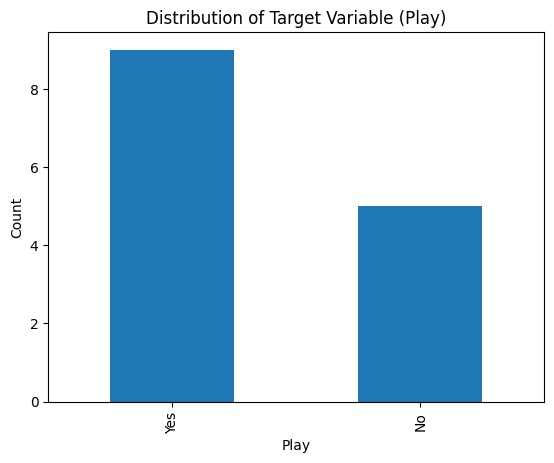

In [9]:
# Step 3: Perform Exploratory Data Analysis (EDA)
# Visualize the distribution of the target variable in the training dataset
print("\nTarget Variable Distribution:")
print(train_data['play'].value_counts())

target_distribution = train_data['play'].value_counts()
target_distribution.plot(kind='bar', title='Distribution of Target Variable (Play)')
plt.xlabel('Play')
plt.ylabel('Count')
plt.show()

In [ ]:
# Analyze categorical feature distributions
for column in ['outlook', 'temp', 'humidity', 'wind']:
    print(f"\nDistribution of {column}:")
    print(train_data[column].value_counts())
    train_data[column].value_counts().plot(kind='bar', title=f'Distribution of {column}')
    plt.xlabel(column)
    plt.ylabel('Count')
    plt.show()

In [ ]:
# Step 5: Initialize and train the Naive Bayes classifier
# Explanation: CategoricalNB is suited for categorical data.
nb_model = CategoricalNB()
nb_model.fit(X_train, y_train)

CategoricalNB()

In [ ]:
# Step 4: Encode categorical variables using LabelEncoder
# Explanation: Naive Bayes in sklearn works with numerical data, so we need to encode text labels.
label_encoders = {}
for column in ['outlook', 'temp', 'humidity', 'wind', 'play']:
    le = LabelEncoder()
    train_data[column] = le.fit_transform(train_data[column])
    test_data[column] = le.transform(test_data[column])
    label_encoders[column] = le

In [ ]:
# Step 5: Split features and target variable
# Explanation: Features are the inputs for the model, and the target variable is what we want to predict.
X_train = train_data[['outlook', 'temp', 'humidity', 'wind']]
y_train = train_data['play']
X_test = test_data[['outlook', 'temp', 'humidity', 'wind']]
y_test = test_data['play']

In [ ]:
# Step 6: Initialize and train the Naive Bayes classifier
# Explanation: CategoricalNB is suited for categorical data.
nb_model = CategoricalNB()
nb_model.fit(X_train, y_train)


CategoricalNB()

In [ ]:
# Step 7: Make predictions on the test set
y_pred = nb_model.predict(X_test)

In [ ]:
# Step 8: Evaluate the model
# Explanation: Evaluate the model's performance using accuracy and a classification report.
accuracy = accuracy_score(y_test, y_pred)
classification_report_output = classification_report(y_test, y_pred, target_names=label_encoders['play'].classes_)

In [ ]:
print("\nModel Accuracy:", accuracy)
print("\nClassification Report:\n", classification_report_output)


Model Accuracy: 0.75

Classification Report:
               precision    recall  f1-score   support

          No       0.50      1.00      0.67         1
         Yes       1.00      0.67      0.80         3

    accuracy                           0.75         4
   macro avg       0.75      0.83      0.73         4
weighted avg       0.88      0.75      0.77         4

